In [21]:
library(immuneSIM)

n_seqs <- 100

sim_repertoire <- immuneSIM(
  name_repertoire = paste0("sim_rep_", n_seqs),
 number_of_seqs = n_seqs,
  species = "hs",
  receptor = "ig",
  chain = "h",
  verbose= TRUE,
  equal_cc = FALSE,
  user_defined_alpha = 2.5,  
  shm = "poisson",
  shm.prob = 30/350,
  vdj_noise = 0,
  max_cdr3_length =17, 
  min_cdr3_length =13,
 
  )
save(sim_repertoire,file="sim_repertoire")

##output plots on repertoire (Note: you need to specify output directory)
plot_report_repertoire(sim_repertoire, output_dir = "../results/plots/plot_report_repertoire")

initializing sim..
simulated sequences: 10 
simulated sequences: 20 
simulated sequences: 30 
simulated sequences: 40 
simulated sequences: 50 
simulated sequences: 60 
simulated sequences: 70 
simulated sequences: 80 
simulated sequences: 90 
simulated sequences: 100 


Ignoring unknown labels:
* colour : ""
Warning message in ggplot2::scale_x_discrete(limit = c(1:number_of_positions)):
"Continuous limits supplied to discrete scale.
i Did you mean `limits = factor(...)` or `scale_*_continuous()`?"
Ignoring unknown labels:
* colour : ""
Ignoring unknown labels:
* fill : ""
* colour : "Repertoire"
Ignoring unknown labels:
* fill : ""
* colour : "Repertoire"
Ignoring unknown labels:
* fill : ""
* colour : "Repertoire"


Plots saved in PDF format in:  ../results/plots/plot_report_repertoire 


Warning message in geom_bar(binwidth = 1, fill = "pink", color = "black"):
"Ignoring unknown parameters: `binwidth`"


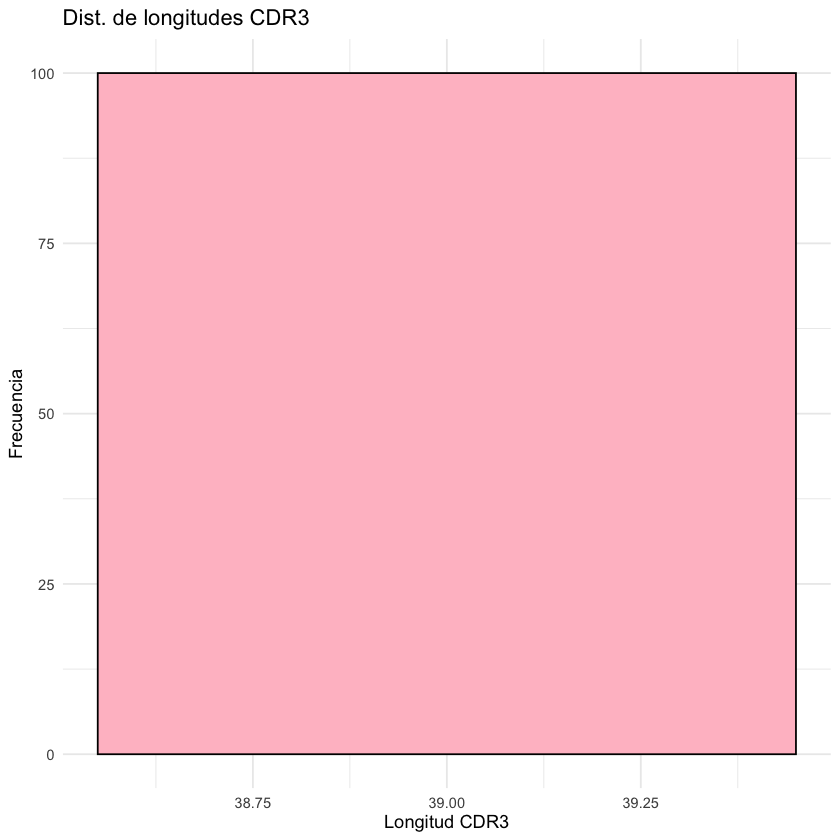

In [1]:
library(readr)
library(ggplot2)
archivo_clones <- "../data/output/repertorio_A_insilico_100_seqs_clone-pass.tsv"
repertorio <- read_tsv(archivo_clones, show_col_types = FALSE)

# 1. Distribución de longitudes CDR3
ggplot(repertorio, aes(x = nchar(cdr3))) +
  geom_bar(binwidth = 1, fill = "pink", color = "black") +
  theme_minimal() +
  labs(title = "Dist. de longitudes CDR3",
       x = "Longitud CDR3",
       y = "Frecuencia")
#

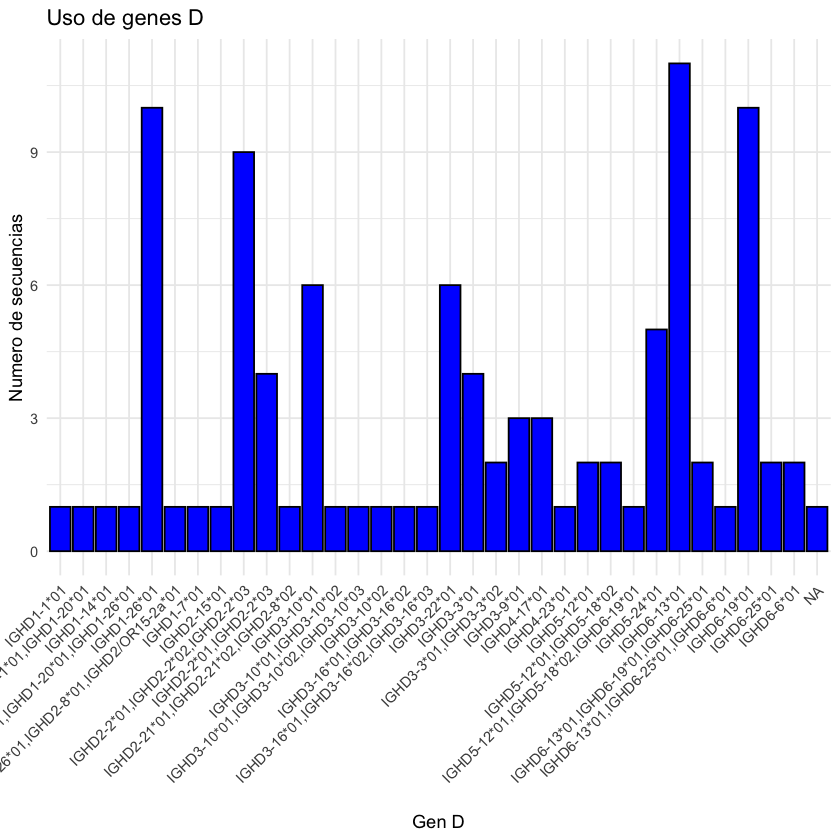

In [2]:
# 3. Uso de genes D
ggplot(repertorio, aes(x = d_call)) +
  geom_bar(fill = "blue", color = "black") +
  theme_minimal() +
  labs(title = "Uso de genes D",
       x = "Gen D",
       y = "Numero de secuencias") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

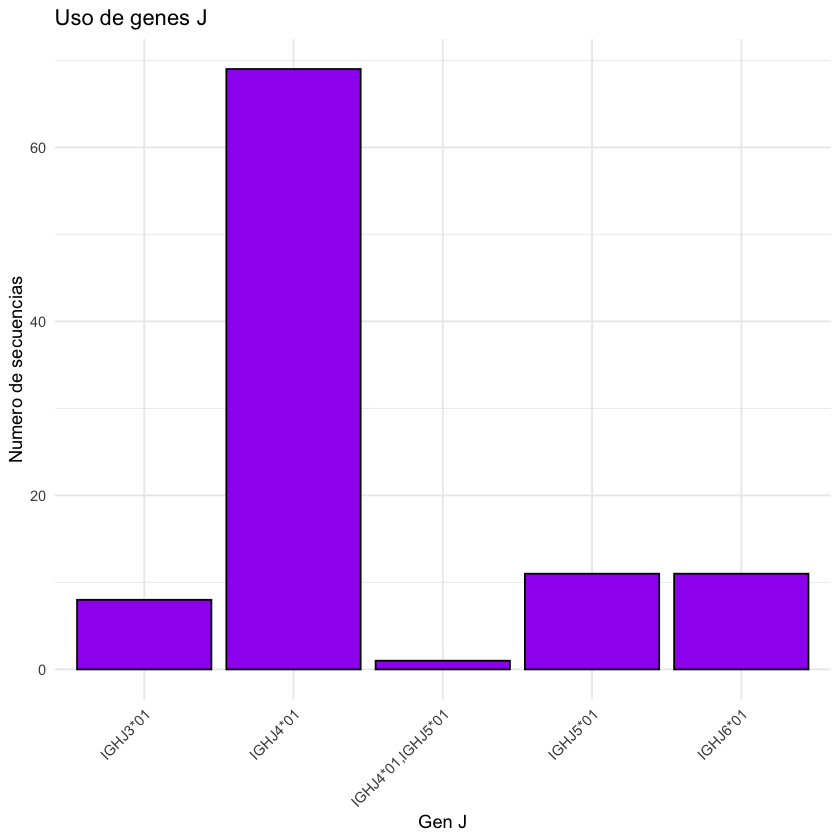

In [3]:
# 3. Uso de genes J
ggplot(repertorio, aes(x = j_call)) +
  geom_bar(fill = "purple", color = "black") +
  theme_minimal() +
  labs(title = "Uso de genes J",
       x = "Gen J",
       y = "Numero de secuencias") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


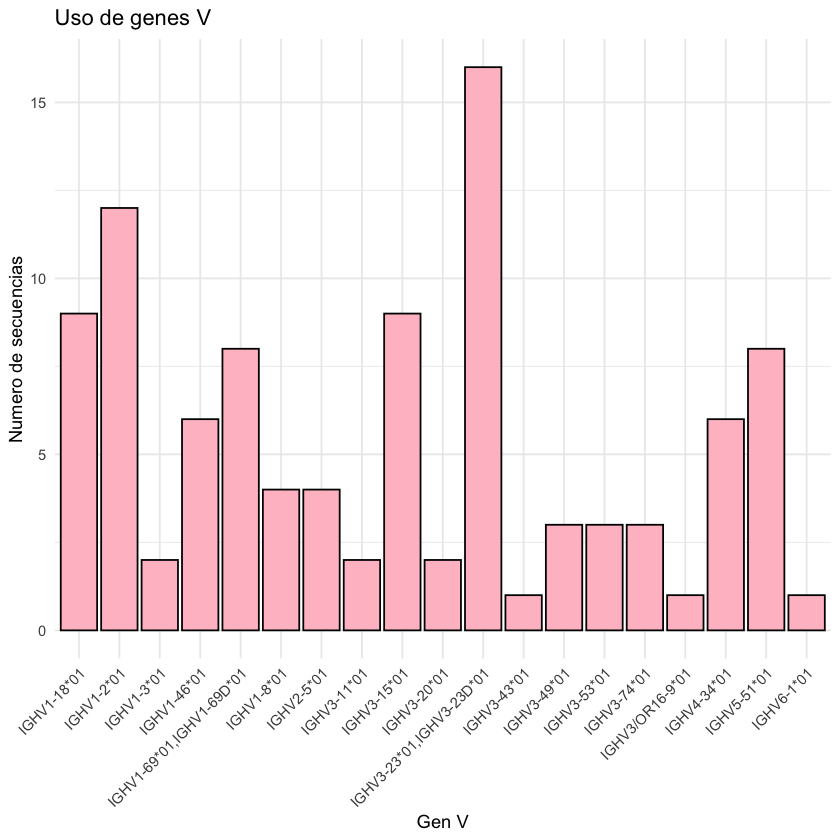

In [4]:
# 3. Uso de genes V
ggplot(repertorio, aes(x = v_call)) +
  geom_bar(fill = "pink", color = "black") +
  theme_minimal() +
  labs(title = "Uso de genes V",
       x = "Gen V",
       y = "Numero de secuencias") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


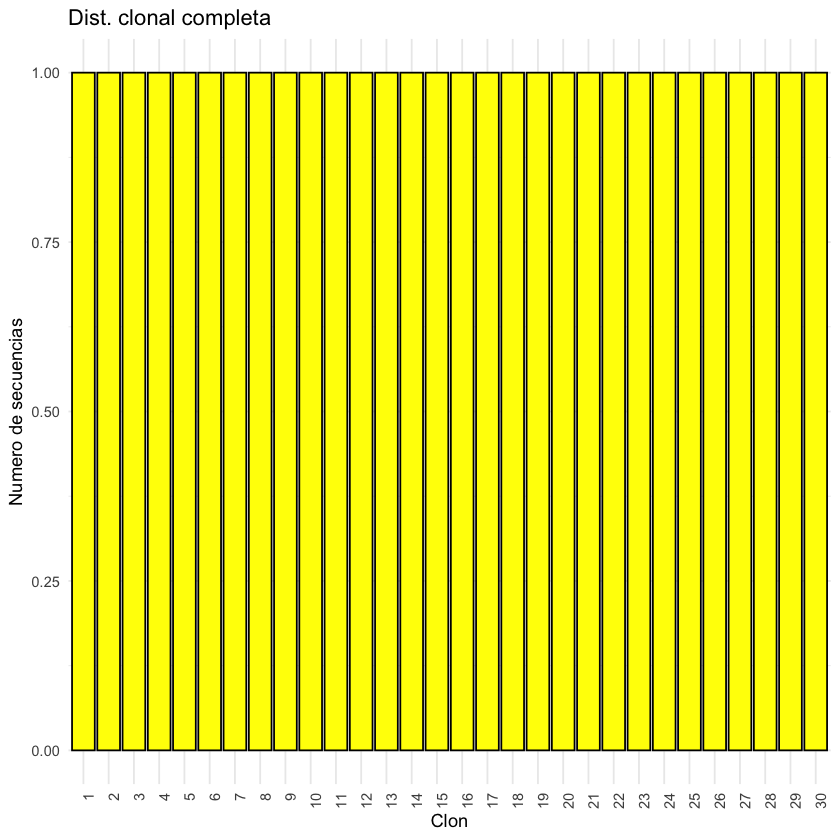

In [14]:

## 4. Distribución clonal completa
clonal_counts <- repertorio %>%
  count(clone_id, name = "freq")

ggplot(clonal_counts, aes(x = reorder(clone_id, -freq), y = freq)) +
  geom_bar(stat = "identity", fill = "yellow", color = "black") +
  theme_minimal() +
  labs(title = "Dist. clonal completa",
       x = "Clon",
       y = "Numero de secuencias") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))